<a href="https://colab.research.google.com/github/seungc1/AivleSchool/blob/main/%EC%A0%84%EC%B2%98%EB%A6%AC_%ED%8C%8C%EC%9D%B4%ED%94%84%EB%9D%BC%EC%9D%B8_%EB%B0%8F_%EB%94%A5%EB%9F%AC%EB%8B%9D_%EB%AA%A8%EB%8D%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### (1) 구글 드라이브 연결 및 경로 설정

- 다음 구문을 실행에 구글 코랩에서 사용 가능하게 연결합니다.

In [ ]:
# 구글 드라이브 연결 & 패스 지정
import sys
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    path = '/content/drive/MyDrive/project01/'
else:
    path = ''

Mounted at /content/drive


### (2) 라이브러리 불러오기

- 이후에 사용할 라이브러리를 모두 불러옵니다.

In [ ]:
# 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import *

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.backend import clear_session
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import load_model

import joblib
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format='retina'

### (3) 학습 곡선 시각화 함수 만들기

- 모델링 수행 시 학습 상황을 시각화해 확인하기 위한 함수를 만듭니다.

In [ ]:
# 함수 만들기
def dl_history_plot(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history['loss'], label='Train Loss', marker='.')
    plt.plot(history['val_loss'], label='Validation Loss', marker='.')

    plt.title('Learning Curve', size=15, pad=20)
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.show()

### (4) 기본 모델 및 데이터 불러오기

- 우선 이전 과정에서 저장한 모델을 불러와 base_model로 선언합니다.
    - path + 'base_model.keras' →  base_model
- **load_model()** 함수를 사용합니다.


In [ ]:
# 모델 불러오기
base_model = load_model(path + 'base_model.keras')

- 이전 과정에서 저장한 스케일러를 불러와 scaler 변수에 저장합니다.
    - path + 'scaler.pkl' →  scaler
- **joblib.load()** 함수를 사용합니다.

In [ ]:
# 스케일러 불러오기
scaler = joblib.load(path + 'scaler.pkl')

- 이전 과정에서 저장한 파일을 읽어와 new_test, new_train 데이터프레임을 만듭니다.
    - path + 'new_test.csv' → new_test
    - path + 'new_train.csv' → new_train

In [ ]:
# 파일 불러오기
new_test = pd.read_csv(path + 'new_test.csv')
new_train = pd.read_csv(path + 'new_train.csv')

## **2. 미션 8: 전처리 파이프라인 만들기**

- 다음 과정을 일괄 처리한 후 x, y를 반환하는 함수를 만듭니다.
    - 결측치 처리
    - Target 값 0/1로 변경
    - 불필요한 변수 제거
    - 라벨 인코딩
    - 가변수화
    - x, y 분리
    - x 스케일링 등
- 함수 이름은 **build_model_input** 로 지정합니다.
- 다음과 같이 사용할 수 있어야 합니다.
    - 예1) x_val, y_val = build_model_input(new_test)
    - 예2) x_trian, y_train = build_model_input(new_train)


In [ ]:
new_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         850 non-null    int64  
 1   ID                                 850 non-null    int64  
 2   Gender                             850 non-null    object 
 3   Customer Type                      850 non-null    object 
 4   Age                                817 non-null    float64
 5   Type of Travel                     850 non-null    object 
 6   Class                              850 non-null    object 
 7   Flight Distance                    850 non-null    int64  
 8   Inflight wifi service              830 non-null    float64
 9   Departure/Arrival time convenient  850 non-null    int64  
 10  Ease of Online booking             850 non-null    int64  
 11  Gate location                      850 non-null    int64  

In [ ]:
new_test.isnull().sum()

,0
Unnamed: 0,0
ID,0
Gender,0
Customer Type,0
Age,10
Type of Travel,0
Class,0
Flight Distance,0
Inflight wifi service,15
Departure/Arrival time convenient,0


In [ ]:
new_train.head()

,Unnamed: 0,ID,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Satisfaction
0,80999,65690,Female,Disloyal Customer,49.0,Business Travel,Business,926,5.0,5,...,2,5,2,5,4,5,2,0,0.0,Satisfied
1,20965,64455,Female,Loyal Customer,12.0,Personal Travel,Eco,989,3.0,3,...,1,2,4,4,4,3,1,5,4.0,Neutral or Dissatisfied
2,91596,1765,Male,Loyal Customer,49.0,Business Travel,Business,2951,4.0,4,...,4,4,4,4,4,4,5,0,0.0,Satisfied
3,64638,22835,Female,Loyal Customer,66.0,Business Travel,Business,302,5.0,5,...,4,4,4,4,4,4,2,0,0.0,Satisfied
4,62001,36581,Female,Loyal Customer,33.0,Business Travel,Business,2873,2.0,3,...,2,2,2,2,2,2,1,0,0.0,Neutral or Dissatisfied


In [ ]:
# 함수 만들기
def build_model_input(data):

    # 1. 결측치 처리
    num_cols = data.select_dtypes(include=['number']).columns
    data[num_cols] = data[num_cols].fillna(data[num_cols].median())

    cat_cols = data.select_dtypes(include=['object', 'category']).columns
    data[cat_cols] = data[cat_cols].fillna(data[cat_cols].mode().loc[0])

    # 2. 값 변경
    data['Satisfaction'] = data['Satisfaction'].map({'Satisfied':1, 'Neutral or Dissatisfied':0})

    # 3. 변수 제거
    drop_cols = ['Unnamed: 0', 'ID']
    data.drop(drop_cols, axis=1, inplace=True)

    # 4. 라벨 인코딩
    cat_cols = ['Gender','Customer Type','Type of Travel','Class']

    for col in cat_cols:
      encoder = LabelEncoder()
      data[col] = encoder.fit_transform(data[col])

    # 5. 가변수화
    categories = [0, 1, 2, 3, 4, 5]

    dumm_cols = ['Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location',
             'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service',
             'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness']

    for col in dumm_cols:
      data[col] = pd.Categorical(data[col], categories=categories)

    data = pd.get_dummies(data, columns=dumm_cols, drop_first=True, dtype=int)

    # 6. x, y 분리
    target = 'Satisfaction'
    x = data.drop(target, axis=1)
    y = data.loc[:, target]

    # 7. 스케일링
    x = scaler.fit_transform(x)


    # 반환
    return x, y

- 점검: 다음 구문이 잘 수행되어 x_val, y_val이 분리되어야 합니다.


In [ ]:
# x_val, y_val 나누기
x_val, y_val = build_model_input(new_test)

# 확인
print(x_val.shape)
print(y_val.shape)

(350, 78)
(350,)


In [ ]:
# 확인
print(x_val.shape)
print(y_val.shape)

(350, 78)
(350,)


## **3. 미션 9: 기본 모델로 예측 및 평가**

### (1) 데이터 전처리

- new_test 데이터프레임을 x_val, y_val로 분리합니다.

In [ ]:
# x_val, y_val 나누기
#x_val, y_val = build_model_input(new_test)


### (2) 예측 및 평가

- 새로운 데이터에 대한 예측과 평가를 수행합니다.

In [ ]:
y_pred = base_model.predict(x_val)
y_pred = np.where(y_pred >= 0.5, 1, 0)
print(classification_report(y_val, y_pred))


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step  
              precision    recall  f1-score   support

           0       0.99      0.82      0.89       191
           1       0.82      0.99      0.89       159

    accuracy                           0.89       350
   macro avg       0.90      0.90      0.89       350
weighted avg       0.91      0.89      0.89       350



## **4. 미션 10: 모델 추가 학습**

### (1) 학습용 데이터 준비

- new_train 데이터프레임을 x_train, y_train으로 분리합니다.

In [ ]:
x_train, y_train = build_model_input(new_train)

print(x_train.shape)
print(y_train.shape)

(850, 78)
(850,)


### (2) 방법 1: 모델 초기화

- 이전에 만들었던 성능이 좋았던 모델과 같은 모델을 만들어 학습 후 성능을 확인합니다.

In [ ]:
clear_session()

# 2. 모델 선언
model = Sequential([
    Input(shape=(x_train.shape[1],)),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])


model.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         2,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,073 (12.00 KB)

 Trainable params: 3,073 (12.00 KB)

 Non-trainable params: 0 (0.00 B)

- 학습 방법을 설정하고 학습을 수행합니다.

In [ ]:
#1. Early Stopping 설정
es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# 2. 모델 컴파일
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 3. 모델 학습 (Early Stopping 콜백 추가)
hist = model.fit(x_train, y_train, epochs=50, validation_data=(x_val, y_val), callbacks=[es], verbose=1).history

Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - accuracy: 0.5141 - loss: 0.7233 - val_accuracy: 0.6429 - val_loss: 0.6631
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6965 - loss: 0.6322 - val_accuracy: 0.7657 - val_loss: 0.6003
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7835 - loss: 0.5556 - val_accuracy: 0.8114 - val_loss: 0.5041
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8259 - loss: 0.4657 - val_accuracy: 0.8457 - val_loss: 0.4075
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8576 - loss: 0.3807 - val_accuracy: 0.8457 - val_loss: 0.3485
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8729 - loss: 0.3198 - val_accuracy: 0.8543 - val_loss: 0.3117
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8824 - loss: 0.2945 - val_accuracy: 0.8571 - val_loss: 0.2891
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9082 - loss: 0.2595 - val_accuracy: 0.8686 - val_los

- 학습 곡선을 확인합니다.

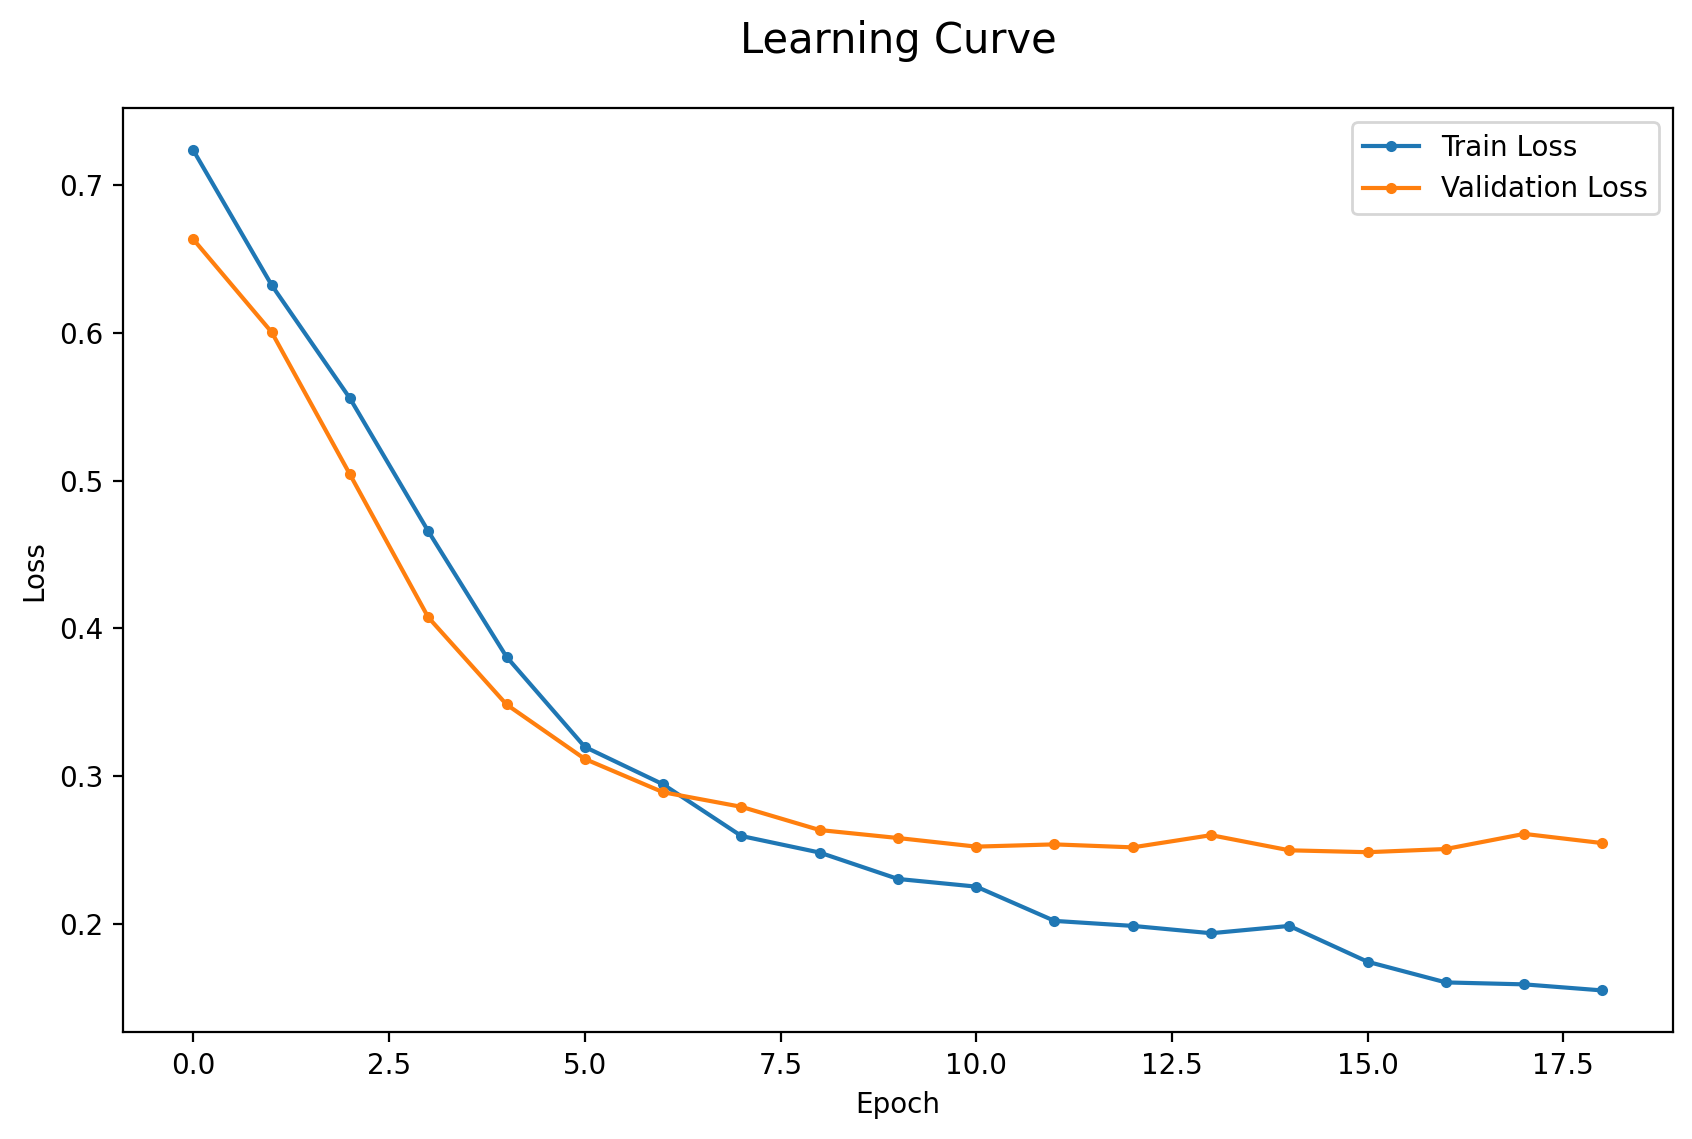

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step


In [ ]:
dl_history_plot(hist)
y_pred = model.predict(x_val)

In [ ]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# from sklearn.metrics import confusion_matrix

# # 오차 행렬 계산
# cm = confusion_matrix(y_val, y_pred)

# # 히트맵으로 시각화
# plt.figure(figsize=(6, 5))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
# plt.xlabel('Predicted')
# plt.ylabel('Actual')
# plt.title('Confusion Matrix', size=15, pad=15)
# plt.show()


- 검증 데이터로 예측 및 평가를 수행합니다.

In [ ]:
y_pred = model.predict(x_val)
y_pred = np.where(y_pred > 0.5, 1, 0)
print(classification_report(y_val, y_pred))

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
              precision    recall  f1-score   support

           0       0.89      0.92      0.90       191
           1       0.90      0.86      0.88       159

    accuracy                           0.89       350
   macro avg       0.90      0.89      0.89       350
weighted avg       0.89      0.89      0.89       350



### (3) 방법 2: 추가 학습

- 기본 모델을 기반으로 모델을 선언하고 추가 학습 후 성능을 확인합니다.

In [ ]:
clear_session
model = base_model

# 2. 모델 선언
model = Sequential([
    Input(shape=(x_train.shape[1],)),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

# 3. 모델 요약
model.summary()



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │         2,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,073 (12.00 KB)

 Trainable params: 3,073 (12.00 KB)

 Non-trainable params: 0 (0.00 B)

- 학습 방법을 설정하고 학습을 수행합니다.

In [ ]:
# 1. Early Stopping 설정
es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# 2. 모델 컴파일
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 3. 모델 학습 (Early Stopping 콜백 추가)
hist = model.fit(x_train, y_train, epochs=50, validation_data=(x_val, y_val), callbacks=[es], verbose=1).history


Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - accuracy: 0.5400 - loss: 0.7166 - val_accuracy: 0.6971 - val_loss: 0.6420
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7141 - loss: 0.6035 - val_accuracy: 0.7429 - val_loss: 0.5646
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7965 - loss: 0.5153 - val_accuracy: 0.7914 - val_loss: 0.4735
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8294 - loss: 0.4158 - val_accuracy: 0.8114 - val_loss: 0.3899
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8706 - loss: 0.3456 - val_accuracy: 0.8543 - val_loss: 0.3363
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8859 - loss: 0.3074 - val_accuracy: 0.8629 - val_loss: 0.3001
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8894 - loss: 0.2749 - val_accuracy: 0.8657 - val_loss: 0.2790
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8988 - loss: 0.2522 - val_accuracy: 0.8800 - val_loss

- 학습 곡선을 확인합니다.

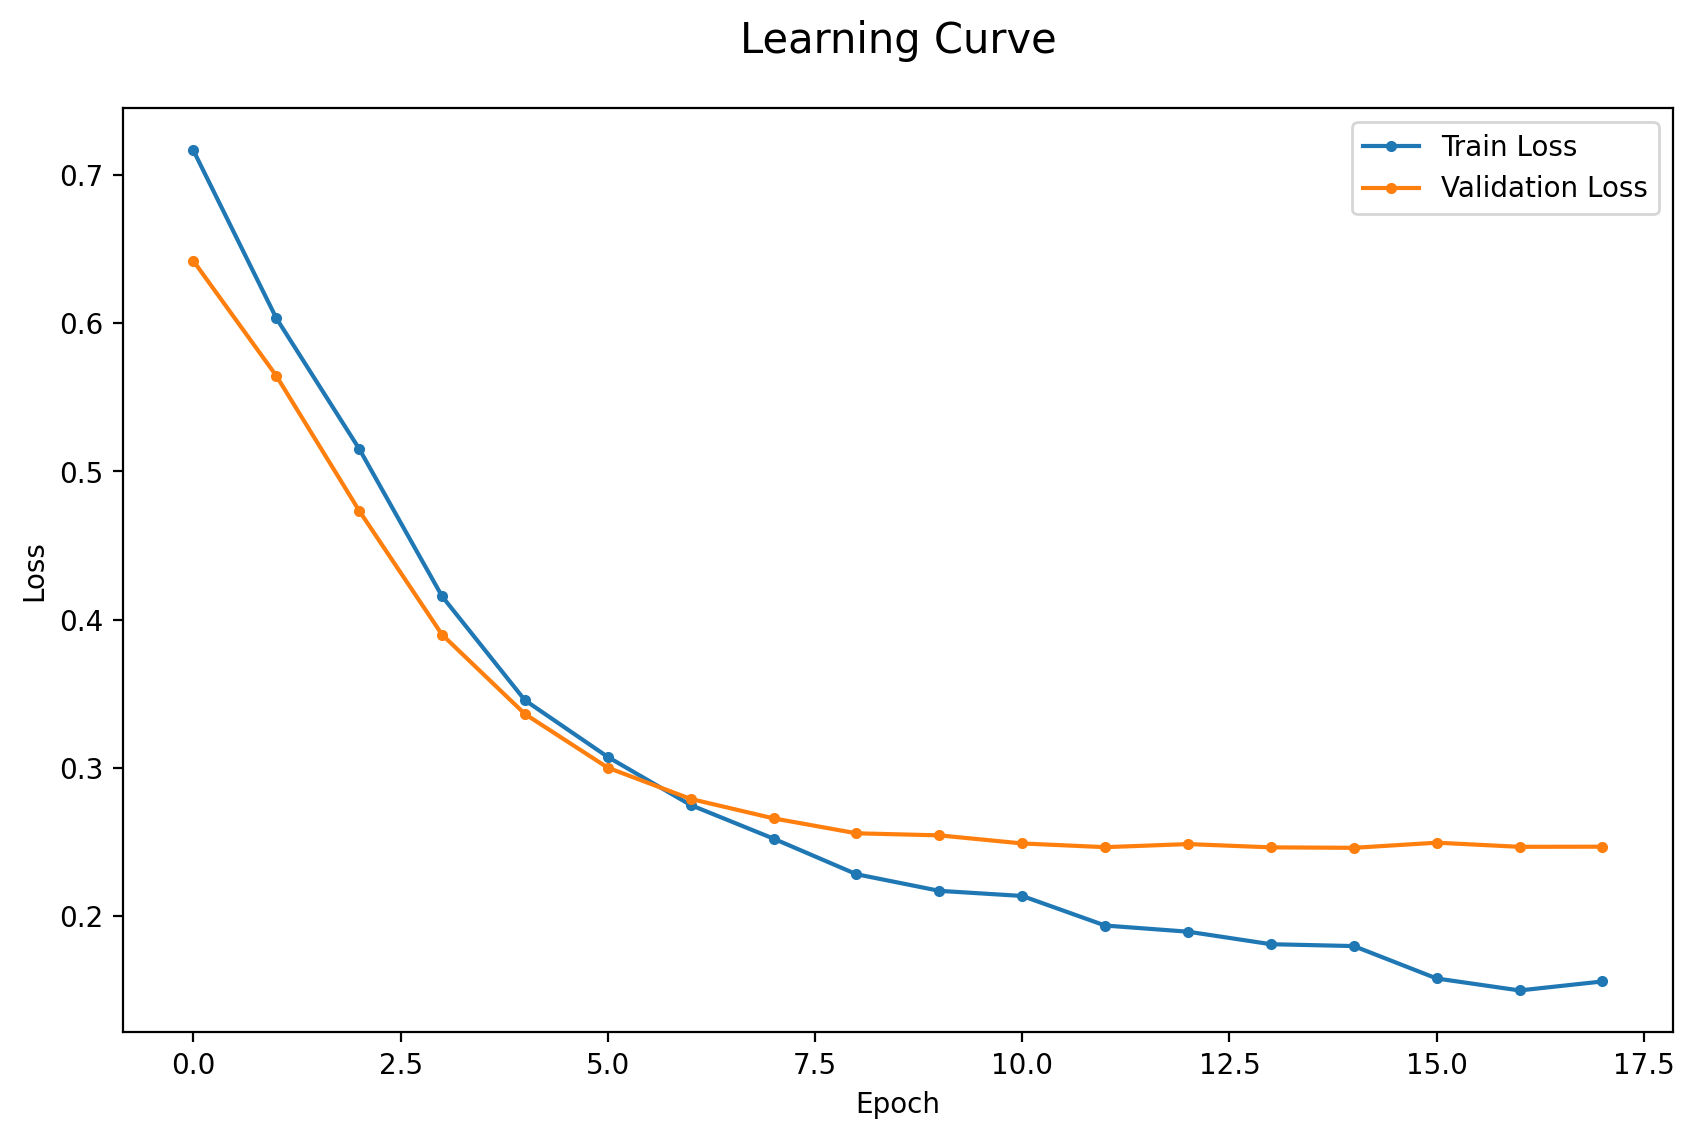

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


In [ ]:
dl_history_plot(hist)
y_pred = model.predict(x_val)

- 검증 데이터로 예측 및 평가를 수행합니다.

In [ ]:
y_pred = model.predict(x_val)
y_pred = np.where(y_pred > 0.5, 1, 0)
print(classification_report(y_val, y_pred))



11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
              precision    recall  f1-score   support

           0       0.90      0.92      0.91       191
           1       0.90      0.87      0.89       159

    accuracy                           0.90       350
   macro avg       0.90      0.90      0.90       350
weighted avg       0.90      0.90      0.90       350



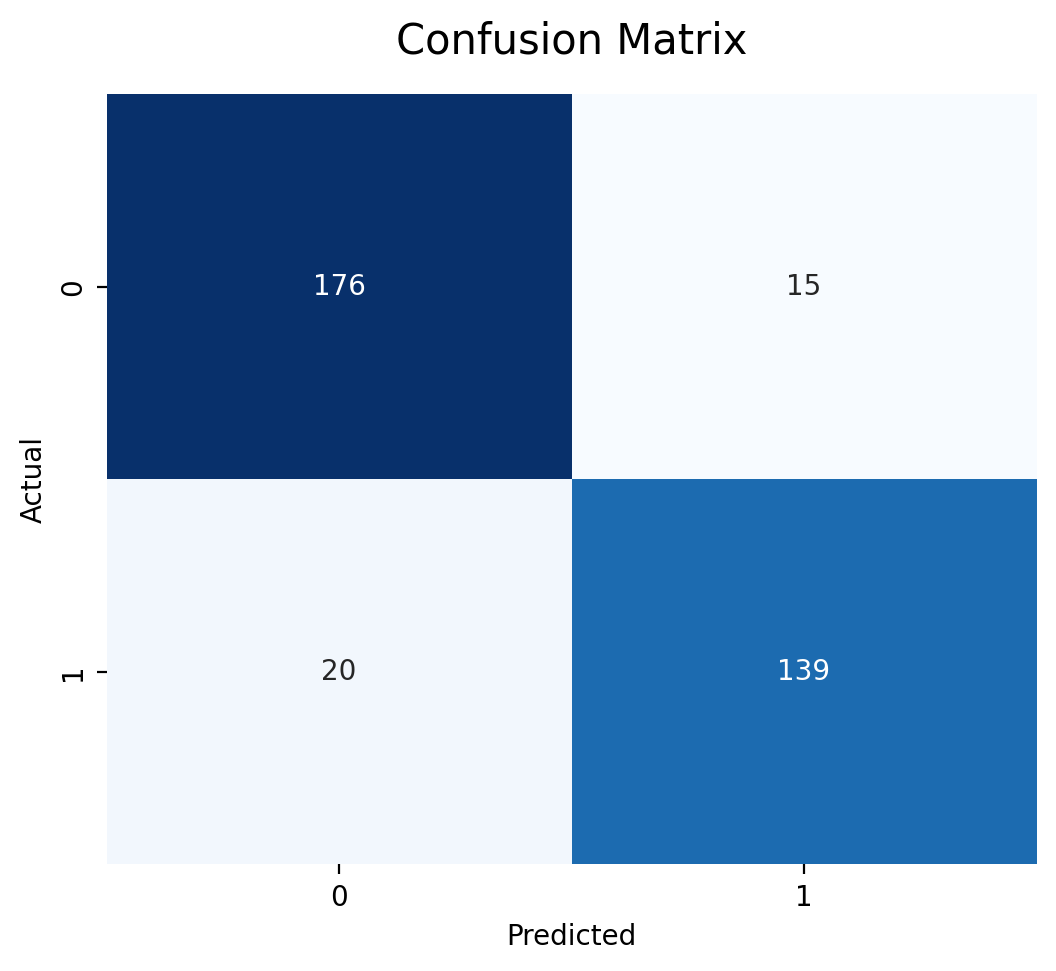

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 오차 행렬 계산
cm = confusion_matrix(y_val, y_pred)

# 히트맵으로 예쁘게 시각화
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix', size=15, pad=15)
plt.show()



### (4) 방법 3: 미세조정

- 기본 모델의 앞쪽 레이어 일부의 학습 기능을 비활성화합니다.
- 기본 모델을 기반으로 레이어를 추가한 모델을 선언합니다.
- 추가 학습을 진행한 뒤 성능을 확인합니다.

In [ ]:
# 모델 불러오기
base_model = load_model(path + 'base_model.keras')

# 마지막 레이어 제거
base_model.pop()

<Dense name=dense_2, built=True>

In [ ]:
for layer in base_model.layers[:-3]:
  layer.trainable = False



- 학습 방법을 설정하고 학습을 수행합니다.

In [ ]:
model = Sequential([
    base_model,
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

# 3. 모델 요약
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 16)             │         3,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,145 (16.19 KB)

 Trainable params: 1,617 (6.32 KB)

 Non-trainable params: 2,528 (9.88 KB)

- 학습 곡선을 확인합니다.

1.   항목 추가
2.   항목 추가




Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 159ms/step - accuracy: 0.8035 - loss: 0.4760 - val_accuracy: 0.9029 - val_loss: 0.3030
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9059 - loss: 0.2896 - val_accuracy: 0.9029 - val_loss: 0.2148
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9247 - loss: 0.2074 - val_accuracy: 0.9029 - val_loss: 0.1879
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9353 - loss: 0.1792 - val_accuracy: 0.9114 - val_loss: 0.1781
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9482 - loss: 0.1504 - val_accuracy: 0.9143 - val_loss: 0.1781
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9365 - loss: 0.1611 - val_accuracy: 0.9229 - val_loss: 0.1750
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9412 - loss: 0.1421 - val_accuracy: 0.9286 - val_loss: 0.1755
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9506 - loss: 0.1458 - val_accuracy: 0.9314 - val_los

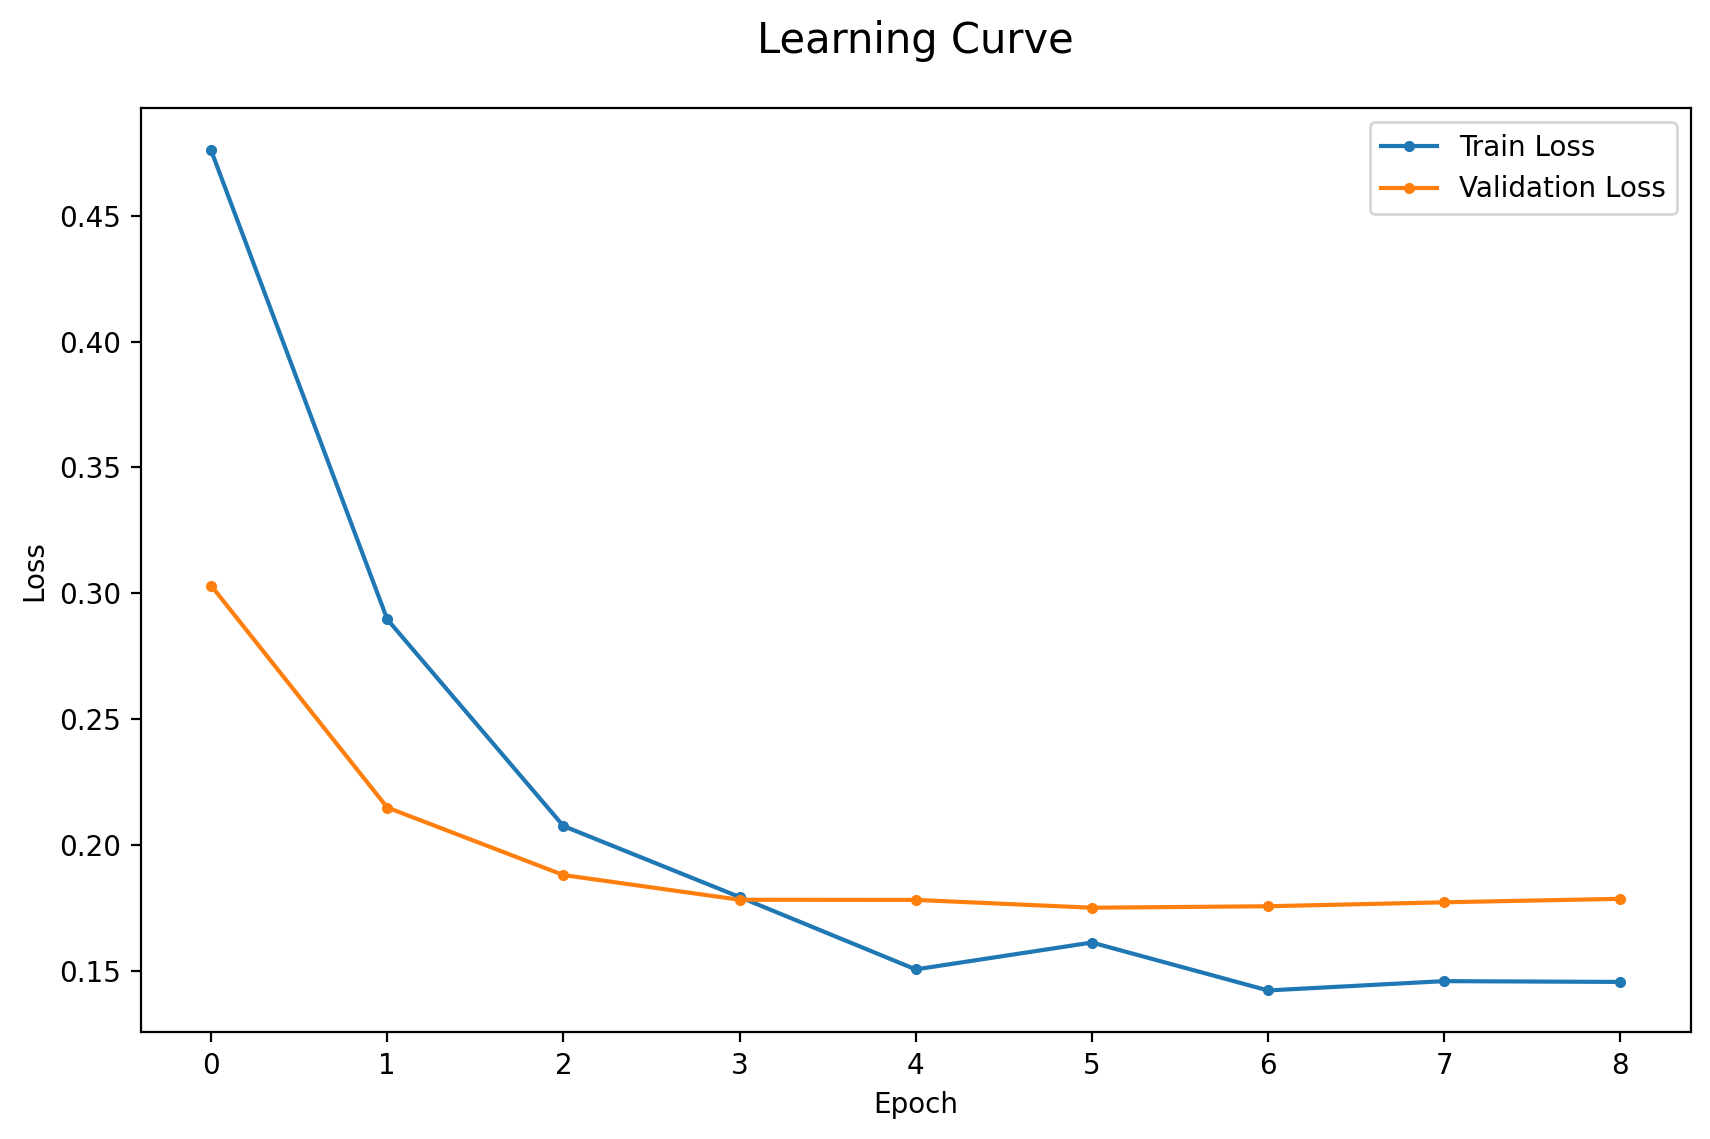

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step


In [ ]:
# 1. Early Stopping 설정
es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# 2. 모델 컴파일
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 3. 모델 학습 (Early Stopping 콜백 추가)
hist = model.fit(x_train, y_train, epochs=50, validation_data=(x_val, y_val), callbacks=[es], verbose=1).history

dl_history_plot(hist)
y_pred = model.predict(x_val)

- 검증 데이터로 예측 및 평가를 수행합니다.

In [ ]:
y_pred = model.predict(x_val)
y_pred = np.where(y_pred > 0.5, 1, 0)
print(classification_report(y_val, y_pred))


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
              precision    recall  f1-score   support

           0       0.95      0.91      0.93       191
           1       0.89      0.94      0.92       159

    accuracy                           0.92       350
   macro avg       0.92      0.92      0.92       350
weighted avg       0.92      0.92      0.92       350

